<h2>Pandas Series</h2>

- A pandas series is like a column in a table.It is a 1-D array holding data of any type.
- It is made above NumPy
- It can only have one column and multiple rows , multiple columns and one row is valid
  but not used.

<h3>Series from lists</h3>

In [45]:
#string 
import pandas as pd
import numpy as np
country=['india','australia','canada','bhutan']
pd.Series(country)
# series has 2 things value and index 
# since dtype is object because pandas called string as objects most of the time.

0        india
1    australia
2       canada
3       bhutan
dtype: object

In [47]:
'''integer'''
runs=[1,14,25,47]
pd.Series(runs)

0     1
1    14
2    25
3    47
dtype: int64

In [49]:
runs=[1,14,25,47]
pd.Series(runs,dtype=np.int32)

0     1
1    14
2    25
3    47
dtype: int32

In [51]:
'''custom index'''
marks=[89,88,78,80]
subjects=['Maths','Science','English','Hindi']
pd.Series(marks,index=subjects)

Maths      89
Science    88
English    78
Hindi      80
dtype: int64

In [53]:
marks=[89,88,78,80]
subjects=['Maths','Science','English','Hindi']
pd.Series(marks,index=subjects,dtype=np.int32)

Maths      89
Science    88
English    78
Hindi      80
dtype: int32

In [55]:
'''setting a name for out series'''
marks=[89,88,78,80]
subjects=['Maths','Science','English','Hindi']
marks_series=pd.Series(marks,index=subjects,dtype=np.int32,name='Rahul_performance')
marks_series #marks is a object of series class.

Maths      89
Science    88
English    78
Hindi      80
Name: Rahul_performance, dtype: int32

In [57]:
pd.Series?

Init signature:
pd.Series(
    data=None,
    index=None,
    dtype: 'Dtype | None' = None,
    name=None,
    copy: 'bool | None' = None,
    fastpath: 'bool | lib.NoDefault' = <no_default>,
) -> 'None'
Docstring:     
One-dimensional ndarray with axis labels (including time series).

Labels need not be unique but must be a hashable type. The object
supports both integer- and label-based indexing and provides a host of
methods for performing operations involving the index. Statistical
methods from ndarray have been overridden to automatically exclude
missing data (currently represented as NaN).

Operations between Series (+, -, /, \*, \*\*) align values based on their
associated index values-- they need not be the same length. The result
index will be the sorted union of the two indexes.

Parameters
----------
data : array-like, Iterable, dict, or scalar value
    Contains data stored in Series. If data is a dict, argument order is
    maintained.
index : array-like or Index (1d)
    

<h3>Series from Dictionary</h3>

In [60]:
marks={
    'maths':89,
    'science':88,
    'english':79,
    'hindi':80}
marks_series=pd.Series(marks,name='Rahul_performance') 

In [62]:
'''here automatically keys become index and values become value'''
marks_series 

maths      89
science    88
english    79
hindi      80
Name: Rahul_performance, dtype: int64

<h3>Series Attributes</h3>

In [65]:
'''size:it tell number of items in our series.'''
print(marks_series)
marks_series.size

maths      89
science    88
english    79
hindi      80
Name: Rahul_performance, dtype: int64


4

In [67]:
''' dtype: it tells the datatype of items stored '''
marks_series.dtype

dtype('int64')

In [69]:
''' Name: describe name of the series '''
marks_series.name

'Rahul_performance'

In [71]:
r={1:'a',2:'b',3:'c'}
s=pd.Series(r)
s

1    a
2    b
3    c
dtype: object

In [73]:
''' is_unique : it tell whether our series items are unique or not '''
print(marks_series.is_unique)
pd.Series([1,2,3,3,2,5]).is_unique

True


False

In [75]:
pd.Series([1,2,3,4,4,5,6,6,7]).is_unique

False

In [77]:
''' index : It give all indexs of all the items '''
marks_series.index

Index(['maths', 'science', 'english', 'hindi'], dtype='object')

In [79]:
runs=[1,14,25,47]
pd.Series(runs).index

RangeIndex(start=0, stop=4, step=1)

In [81]:
''' values: return all the values of items inside numpy array '''
marks_series.values

array([89, 88, 79, 80], dtype=int64)

In [83]:
type(marks_series.values)

numpy.ndarray

<h3>Series using read_csv</h3>

Since by default read_csv reads the data and store it in a dataframe form , to store
it in series form we use ***squeeze***

In [86]:
''' with one col'''
pd.read_csv("subs.csv") #by default stoe the read data in form of dataframe.

,Subscribers gained
0,48
1,57
2,40
3,43
4,44
...,...
360,231
361,226
362,155
363,144


In [88]:
type(pd.read_csv("subs.csv"))

pandas.core.frame.DataFrame

In [90]:
subs=pd.read_csv("subs.csv",squeeze=True)
subs #squeeze is removed from pandas

TypeError: read_csv() got an unexpected keyword argument 'squeeze'

In [92]:
subs=pd.read_csv("subs.csv",dtype='int32').squeeze('columns')
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int32

In [94]:
pd.read_csv("kohli_ipl")

FileNotFoundError: [Errno 2] No such file or directory: 'kohli_ipl'

In [ ]:
''' with two columns'''
pd.read_csv("kohli_ipl.csv")

In [97]:
pd.read_csv("kohli_ipl.csv").squeeze('columns') # this will not provide series as there are 2 columns

,match_no,runs
0,1,1
1,2,23
2,3,13
3,4,12
4,5,1
...,...,...
210,211,0
211,212,20
212,213,73
213,214,25


In [158]:
vk=pd.read_csv(("kohli_ipl.csv"),index_col='match_no').squeeze('columns')
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [101]:
vk=pd.read_csv(("kohli_ipl.csv")).squeeze('columns')
vk

,match_no,runs
0,1,1
1,2,23
2,3,13
3,4,12
4,5,1
...,...,...
210,211,0
211,212,20
212,213,73
213,214,25


In [103]:
''' bollywood csv'''
bollywood= pd.read_csv(("bollywood.csv"),index_col='movie').squeeze('columns')
bollywood #always the name of the series will be the column name whose items are inside values of series

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

<h3>Series Methods</h3>

In [106]:
''' head() : it gives the preview of the data by provide top 5 rows by default. but we 
can change the number of rows we want ot see'''
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int32

In [108]:
subs.head()

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int32

In [110]:
subs.head(50)

0      48
1      57
2      40
3      43
4      44
5      46
6      33
7      40
8      44
9      74
10     49
11     56
12     49
13     42
14     39
15     44
16     54
17     51
18     40
19     37
20     40
21     45
22     50
23     56
24     35
25     49
26     46
27     88
28     61
29     42
30     56
31     50
32     50
33     49
34     76
35    123
36    108
37    110
38     56
39     62
40     65
41     66
42     33
43     66
44     82
45    126
46    109
47     88
48     83
49    108
Name: Subscribers gained, dtype: int32

In [112]:
''' tail(): it gives the preview of last 5 rows '''
subs.tail()

360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, dtype: int32

In [114]:
subs.tail(10)

355    149
356    156
357    177
358    210
359    209
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, dtype: int32

In [120]:
''' sample(): it randomy shows one row from the data. Here also we can provide #from here we get that sample=row
size of sample(no. of rows) but by default it gives only 1 row'''
bollywood
bollywood.sample()

movie
Calcutta Mail    Anil Kapoor
Name: lead, dtype: object

In [122]:
bollywood.sample(10) # randomly selected movies, use sample when there is any kind of 
#biasness in your data

movie
Dear Zindagi                         Alia Bhatt
Kyon Ki                             Salman Khan
Rough Book                Tannishtha Chatterjee
5 Weddings                        Nargis Fakhri
Andaaz                             Akshay Kumar
Hope Aur Hum                   Naseeruddin Shah
Bhola in Bollywood                    Ali Asgar
Gone Kesh                          Deepika Amin
Tahaan                          Victor Banerjee
Half Girlfriend (film)          Shraddha Kapoor
Name: lead, dtype: object

In [130]:
''' value_counts: it tells the count/frequency of each value'''
bollywood.value_counts()

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
                    ..
Diganth              1
Parveen Kaur         1
Seema Azmi           1
Akanksha Puri        1
Edwin Fernandes      1
Name: count, Length: 566, dtype: int64

,match_no,runs
0,1,1
1,2,23
2,3,13
3,4,12
4,5,1
...,...,...
210,211,0
211,212,20
212,213,73
213,214,25


In [172]:
'''sort_values(): it sorts the values. By default it sorts in ascending order, but we cn 
sort in descending order by assinging ascending parameter False'''
vk.sort_values()

match_no
87       0
211      0
207      0
206      0
91       0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64

In [170]:
vk.sort_values(ascending=False).head(1) #it will give top row

match_no
128    113
Name: runs, dtype: int64

In [92]:
vk.sort_values(ascending=False).head(1).values #if we just want to value not the index

array([113], dtype=int64)

In [94]:
vk.sort_values(ascending=False).head(1).values[0] #if we just want value no np array

113

In [96]:
vk #all the sort values are tempory  change but if we want we can permanently chnage it 
#using inplace parameter . By setting its value to true changes will be made permamnently.

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [98]:
''' sort_index(): it is used to sort the index of the series'''
print(bollywood)
bollywood.sort_index().head(50)

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object


movie
1920 (film)                            Rajniesh Duggall
1920: London                              Sharman Joshi
1920: The Evil Returns                      Vicky Ahuja
1971 (2007 film)                         Manoj Bajpayee
2 States (2014 film)                       Arjun Kapoor
22 Yards                                    Barun Sobti
3 A.M. (2014 film)                        Salil Acharya
3 Deewarein                            Naseeruddin Shah
3 Idiots                                     Aamir Khan
3 Storeys                                   Aisha Ahmed
31st October (film)                       Soha Ali Khan
36 China Town                            Akshaye Khanna
3G (film)                             Neil Nitin Mukesh
404 (film)                                   Sara Arjun
5 Weddings                                Nargis Fakhri
68 Pages                                  Mouli Ganguly
7 Hours to Go                              Vipin Sharma
7 Khoon Maaf                            Pr

<h3>Series Maths Methods</h3>

In [101]:
''' count: it gives you the no. of obeservation present in a series. It count only non missing 
values. If there are mising values it will not count them. whereas size count them.'''
vk.count()

215

In [103]:
''' sum:it will add all the items of a series. '''
subs.sum()

49510

In [105]:
'''product : it will give product of all items in series.'''
subs.product() #it is zero because there might be somedays when no subscribers were gain

0

<h3>statistical methods</h3>

In [108]:
''' mean'''
print(subs.mean())
print(vk.median())

135.64383561643837
24.0


In [110]:
''' median'''
print(subs.median())
print(vk.median())


123.0
24.0


In [112]:
'''mode'''
bollywood.mode() #0 is the index

0    Akshay Kumar
Name: lead, dtype: object

In [114]:
''' standard deviation'''
subs.std()

62.67502303725269

In [116]:
''' min/max'''
print(subs.max()) #max no.of subscribers gained in entire year
print(subs.min()) #min no.of subscribers gained in entire year

396
33


In [118]:
''' describe() : it gies the summary of descriptive statistics'''
subs.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64

In [120]:
vk.describe()

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64

<h3>Series Indexing</h3>

In [123]:
x=pd.Series([12,13,14,15,16,17,34,65,89])
x[0]

12

In [125]:
x[1]

13

In [127]:
''' negative indexing : series does not work in negative indexing directly as in list,
numpy etc. Use .iloc for negative indexing in Pandas.'''
x[-1]

KeyError: -1

In [ ]:
bollywood[0]

In [182]:
'''iloc: .iloc is a way to access data in a DataFrame or Series based on their position 
(row or column index). 
it allows you to access rows or columns using their index positions (like 0, 1, 2, etc.).'''

bollywood.iloc[0]

'Vicky Kaushal'

In [132]:
bollywood[-1]

C:\Users\acer\AppData\Local\Temp\ipykernel_532\4136197083.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bollywood[-1]


'Akshay Kumar'

In [134]:
bollywood.iloc[-1]

'Akshay Kumar'

In [136]:
vk.iloc[-1]

7

<h3>Series Slicing</h3>

- 1. Slicing with .loc (Label-Based Indexing)
    - Start Index: Included.
    - End Index: Included.
    - This is different from Python slicing behavior in lists, where the end index is  excluded
- 2.Slicing with .iloc (Position-Based Indexing)
  - Start Index: Included.
  - End Index: Excluded (like Python slicing in lists or NumPy arrays).


In [139]:
''' runs between 5 to 15'''
vk[5:16] #it print index values not indexes

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
16     2
Name: runs, dtype: int64

In [189]:
row=[1,2,4]
vk.loc[row] #print the 1st,2nd and 4th row.

match_no
1     1
2    23
4    12
Name: runs, dtype: int64

In [141]:
vk.iloc[5:15]

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
Name: runs, dtype: int64

In [143]:
vk.iloc[-5:-1]

match_no
211     0
212    20
213    73
214    25
Name: runs, dtype: int64

In [145]:
''' fancy indexing'''
vk.iloc[[1,2,3,4]] #vk.iloc([indexes])

match_no
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [147]:
bollywood['2 States (2014 film)']

'Arjun Kapoor'

<h3>Editing Series</h3>

In [150]:
''' using indexing'''
print(marks_series)
marks_series.iloc[0]=90
marks_series.iloc[1]=89

maths      89
science    88
english    79
hindi      80
Name: Rahul_performance, dtype: int64


In [152]:
marks_series

maths      90
science    89
english    79
hindi      80
Name: Rahul_performance, dtype: int64

In [154]:
''' what if an index does not exist'''
marks_series['sst']=90 # a new item is added to our series 

In [195]:
marks_series.loc['maths']=89 # use loc if index does not exist.

In [197]:
marks_series

maths      89
science    88
english    79
hindi      80
Name: Rahul_performance, dtype: int64

In [158]:
''' slicng'''
x

0    12
1    13
2    14
3    15
4    16
5    17
6    34
7    65
8    89
dtype: int64

In [160]:
x.iloc[2:4]=[100,100]
x

0     12
1     13
2    100
3    100
4     16
5     17
6     34
7     65
8     89
dtype: int64

In [162]:
''' fancy indexing'''
x[[0,3,4]]=[0,0,0]
x

0      0
1     13
2    100
3      0
4      0
5     17
6     34
7     65
8     89
dtype: int64

In [164]:
bollywood.sort_index()

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object

In [166]:
bollywood['2 States (2014 film)']='Alia bhatt, Arjun kapoor'
bollywood.sort_index()

movie
1920 (film)                         Rajniesh Duggall
1920: London                           Sharman Joshi
1920: The Evil Returns                   Vicky Ahuja
1971 (2007 film)                      Manoj Bajpayee
2 States (2014 film)        Alia bhatt, Arjun kapoor
                                      ...           
Zindagi 50-50                            Veena Malik
Zindagi Na Milegi Dobara              Hrithik Roshan
Zindagi Tere Naam                 Mithun Chakraborty
Zokkomon                             Darsheel Safary
Zor Lagaa Ke...Haiya!                  Meghan Jadhav
Name: lead, Length: 1500, dtype: object

In [168]:
x=[1,2,3,4]
x_series=pd.Series(x)
id(x)

2140395130752

In [170]:
id(x_series.sort_values()) # therefore series is immutable.

2140343898896

<h3>Series with python fundamentals</h3>

In [173]:
''' len/dir/type/sorted/max/min'''
print(len(subs))
print(type(vk))
print(dir(vk))
print(sorted(vk)) #it sorts the series but store it in list.


365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce

In [175]:
print(max(subs))
print(min(subs))

396
33


In [182]:
''' type conversion'''
marks_series # we can convert series into different datatype

maths      90
science    89
english    79
hindi      80
sst        90
Name: Rahul_performance, dtype: int64

In [184]:
list(marks_series)

[90, 89, 79, 80, 90]

In [186]:
dict(marks_series)

{'maths': 90, 'science': 89, 'english': 79, 'hindi': 80, 'sst': 90}

In [188]:
''' membership operator'''
bollywood

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

In [190]:
'Evening Shadows' in bollywood  

True

In [192]:
"Alia Bhatt" in bollywood # in operator is only applicable in index not in values.

False

In [194]:
''' looping'''
# for i in bollywood:
#     print(i)

' looping'

In [177]:
# for i in bollywood.index:
    # print(i)

In [179]:
''' Arithmetic operator'''
marks_series

maths      90
science    89
english    79
hindi      80
sst        90
Name: Rahul_performance, dtype: int64

In [181]:
100-marks_series #it is a example of broadcasting '''

maths      10
science    11
english    21
hindi      20
sst        10
Name: Rahul_performance, dtype: int64

In [183]:
''' Relational operators'''
vk>=50 #this will return boolean series


match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

<h3>Boolean Indexing</h3>


In [186]:
''' find no of 50's score and 100 score by vikrat kohli'''
vk>=50
vk[vk>=50]

match_no
15      50
34      58
41      71
44      56
45      67
52      70
57      57
68      73
71      51
73      58
74      65
80      57
81      93
82      99
85      56
97      67
99      73
103     51
104     62
110     82
116     75
117     79
119     80
120    100
122     52
123    108
126    109
127     75
128    113
129     54
131     54
132     62
134     64
137     55
141     58
144     57
145     92
148     68
152     70
160     84
162     67
164    100
175     72
178     90
182     50
188     72
197     51
198     53
209     58
213     73
Name: runs, dtype: int64

In [188]:
vk[vk>=50].size
# in 50 matches virat kohli made runs greater then or equal to 50

50

In [190]:
''' find the no of ducks'''
vk==0
vk[vk==0]

match_no
8      0
87     0
91     0
93     0
130    0
135    0
206    0
207    0
211    0
Name: runs, dtype: int64

In [192]:
''' count number of day when the youtuber gained more than 200 subs a day'''
subs>200
subs[subs>200]

165    225
166    249
167    265
168    306
169    261
170    222
225    224
226    254
227    214
228    236
229    261
230    247
231    207
232    254
233    301
234    233
240    202
246    259
248    213
249    210
252    216
275    228
276    237
277    276
279    290
280    295
281    245
282    241
283    267
284    269
285    211
287    206
288    202
290    236
291    222
292    203
312    230
318    244
324    243
325    227
326    259
330    396
331    312
332    268
333    229
337    221
338    225
339    221
340    202
344    276
345    258
346    219
347    212
351    220
354    204
358    210
359    209
360    231
361    226
Name: Subscribers gained, dtype: int32

In [194]:
subs[subs>200].size

59

In [196]:
''' find actors who have doine more than 20 movies'''
num_movies=bollywood.value_counts()
num_movies>20
num_movies[num_movies>20]

lead
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Shah Rukh Khan      22
Emraan Hashmi       21
Name: count, dtype: int64

<h3>Plotting graphs on Series</h3>

In [199]:
import pandas as pd

<Axes: >

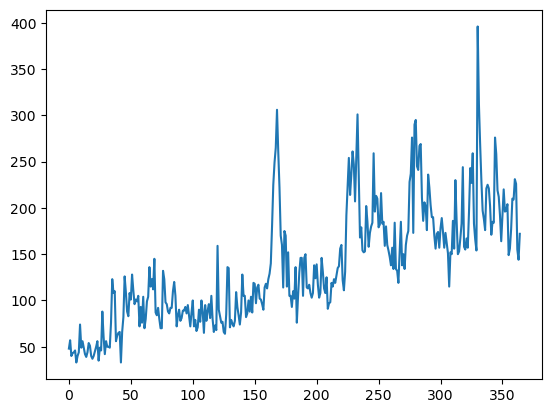

In [201]:
subs.plot(x='days')

<Axes: xlabel='lead'>

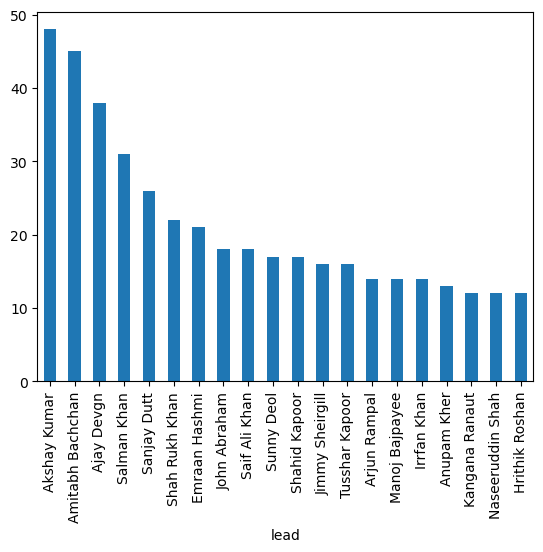

In [202]:
bollywood .value_counts().head(20).plot(kind='bar')

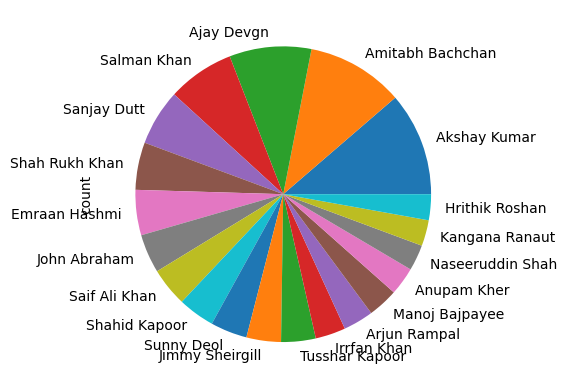

In [199]:
bollywood .value_counts().head(20).plot(kind='pie');

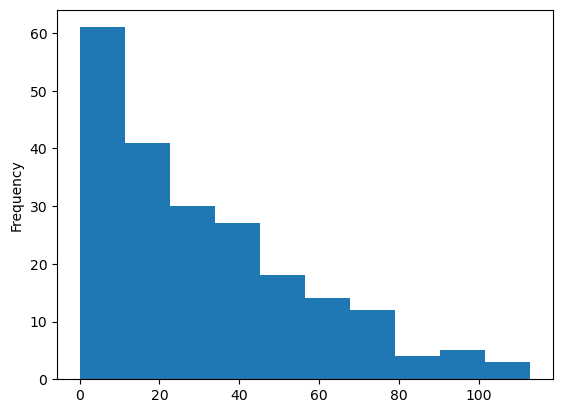

In [205]:
vk.plot(kind='hist');

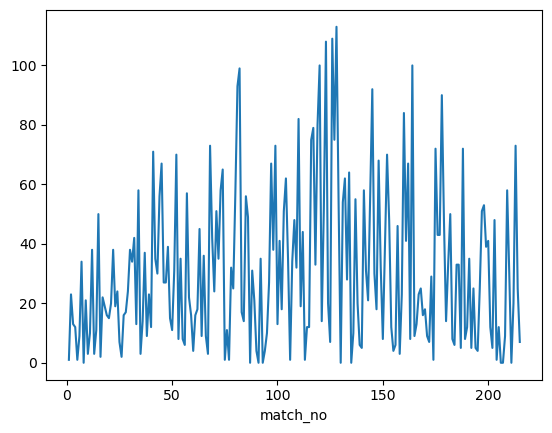

In [207]:
vk.plot();

In [211]:
''' astype() : The astype() method returns a new DataFrame where the data types 
has been changed to the specified type.'''
vk

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [213]:
import sys
sys.getsizeof(vk)

3472

In [215]:
vk.astype('int32')

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int32

In [217]:
sys.getsizeof(vk.astype('int32'))

2612

In [219]:
sys.getsizeof(vk.astype('int16'))

2182

In [221]:
'''between() : it tells whether the values lies within a range , it return a boolean series'''
vk.between(51,99)

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool

In [223]:
vk[vk.between(51,99)]

match_no
34     58
41     71
44     56
45     67
52     70
57     57
68     73
71     51
73     58
74     65
80     57
81     93
82     99
85     56
97     67
99     73
103    51
104    62
110    82
116    75
117    79
119    80
122    52
127    75
129    54
131    54
132    62
134    64
137    55
141    58
144    57
145    92
148    68
152    70
160    84
162    67
175    72
178    90
188    72
197    51
198    53
209    58
213    73
Name: runs, dtype: int64

In [225]:
vk[vk.between(51,99)].size

43

In [227]:
''' clip() : it clip(to put the values within a range) in the given range'''
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int32

In [229]:
subs.clip(100,200) # the values less than 100 are changed to 100 and values greater than 200
#are changed to 200

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int32

In [231]:
''' drop_duplicates(): it removes the duplicate values, we can even make choice of which one
to remove first occurance or last'''
temp=pd.Series([1,2,3,4,5,4,2,6,2,])
temp

0    1
1    2
2    3
3    4
4    5
5    4
6    2
7    6
8    2
dtype: int64

In [243]:
temp.drop_duplicates()

0    1
1    2
2    3
3    4
4    5
7    6
dtype: int64

In [263]:
a=[1,2,4,4,5,6,7,6,5,5]
s=pd.Series(a)

In [261]:
s

0    1
1    2
2    4
3    4
4    5
5    6
6    7
7    6
8    5
9    5
dtype: int64

In [265]:
s.drop_duplicates(keep='first') #by default first

0    1
1    2
2    4
4    5
5    6
6    7
dtype: int64

In [267]:
s.drop_duplicates(keep='last')

0    1
1    2
3    4
6    7
7    6
9    5
dtype: int64

In [269]:
bollywood.drop_duplicates()

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 567, dtype: object

In [276]:
s.duplicated() #values which have duplicates

0    False
1    False
2    False
3     True
4    False
5    False
6    False
7     True
8     True
9     True
dtype: bool

In [278]:
s.duplicated().sum()

4

In [284]:
vk.duplicated().sum() #total 137 duplicated values are there.

137

In [ ]:
''' isnull'''

In [292]:
temp=pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
temp

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64

In [294]:
temp.count() #giving only non null values

7

In [300]:
temp.size # give total number of values.

10

In [306]:
temp.isnull()

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8     True
9    False
dtype: bool

In [316]:
temp.isnull().sum() #total number of missing values.


3

In [312]:
vk.isnull().sum()

0

In [314]:
subs.isnull().sum()

0

In [320]:
'''dropna: it is used to remove all the null values'''
temp.dropna() #return new series with no null values.

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64

In [322]:
'''fillna : it is used to fill the null values'''
temp.fillna(0)

0     1.0
1     2.0
2     3.0
3     0.0
4     5.0
5     6.0
6     0.0
7     8.0
8     0.0
9    10.0
dtype: float64

In [326]:
a=temp.mean()
temp.fillna(a)

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

In [336]:
temp.fillna(temp.median())

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

In [344]:
''' isin : it check multiple things at one go'''
vk[(vk==49) |( vk==99)]

match_no
82    99
86    49
Name: runs, dtype: int64

In [350]:
vk[vk.isin([49,99,50])] #here we indexed the condition inside the vk to get only values where
#condition is true

match_no
15     50
82     99
86     49
182    50
Name: runs, dtype: int64

In [354]:
bollywood[bollywood=='Akshay Kumar']

movie
Kesari (film)                           Akshay Kumar
Mission Mangal                          Akshay Kumar
Housefull 4                             Akshay Kumar
Good Newwz                              Akshay Kumar
Gold (2018 film)                        Akshay Kumar
Toilet: Ek Prem Katha                   Akshay Kumar
Airlift (film)                          Akshay Kumar
Baby (2015 Hindi film)                  Akshay Kumar
Singh Is Bliing                         Akshay Kumar
Gabbar Is Back                          Akshay Kumar
Gabbar Is Back                          Akshay Kumar
Brothers (2015 film)                    Akshay Kumar
Holiday: A Soldier Is Never Off Duty    Akshay Kumar
Entertainment (2014 film)               Akshay Kumar
The Shaukeens                           Akshay Kumar
Special 26                              Akshay Kumar
Once Upon ay Time in Mumbai Dobaara!    Akshay Kumar
Boss (2013 Hindi film)                  Akshay Kumar
Joker (2012 film)                       

In [368]:
bollywood[bollywood.isin(['Akshay Kumar',' Ajay Devgn'])]

movie
Kesari (film)                           Akshay Kumar
Mission Mangal                          Akshay Kumar
Housefull 4                             Akshay Kumar
Good Newwz                              Akshay Kumar
Gold (2018 film)                        Akshay Kumar
Toilet: Ek Prem Katha                   Akshay Kumar
Airlift (film)                          Akshay Kumar
Baby (2015 Hindi film)                  Akshay Kumar
Singh Is Bliing                         Akshay Kumar
Gabbar Is Back                          Akshay Kumar
Gabbar Is Back                          Akshay Kumar
Brothers (2015 film)                    Akshay Kumar
Holiday: A Soldier Is Never Off Duty    Akshay Kumar
Entertainment (2014 film)               Akshay Kumar
The Shaukeens                           Akshay Kumar
Special 26                              Akshay Kumar
Once Upon ay Time in Mumbai Dobaara!    Akshay Kumar
Boss (2013 Hindi film)                  Akshay Kumar
Joker (2012 film)                       

In [378]:
subs.isin([23,137,50])

0      False
1      False
2      False
3      False
4      False
       ...  
360    False
361    False
362    False
363    False
364    False
Name: Subscribers gained, Length: 365, dtype: bool

In [380]:
subs[subs.isin([23,137,50])]

22      50
31      50
32      50
218    137
Name: Subscribers gained, dtype: int32

In [382]:
''' apply : it used to apply cutom logic to our series'''
bollywood

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

In [211]:
# now i want only first name of all actors and in uppercase

bollywood.apply(lambda x:x.split()[].upper())

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: object

In [392]:
subs

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int32

In [408]:
# i want to call all the days wher subscribers gained are more than avg an happy day
avg=subs.median()
subs.apply(lambda x:'happy day' if x>avg else 'sad day')

0        sad day
1        sad day
2        sad day
3        sad day
4        sad day
         ...    
360    happy day
361    happy day
362    happy day
363    happy day
364    happy day
Name: Subscribers gained, Length: 365, dtype: object

In [434]:
''' when we use head or tail then we are getting preview of the original data now the co
py of the data , so the changes made using head tail will reflect the original data.'''
vk.head()

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [447]:
''' copy: it provide the copy of original series'''
new=vk.head().copy()
new

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64

In [438]:
new[1]=100
new

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64

In [445]:
print(vk.head())
print("   ")
print(new.head())

match_no
1     1
2    23
3    13
4    12
5     1
Name: runs, dtype: int64
   
match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64
